In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [68]:
veltro = pd.read_csv("veltro_synthetic_deals.csv")
print(veltro.head())
print(veltro.info())
print(veltro.describe())



  company_id                 industry      geography     ownership_type  \
0     C00001  Specialty manufacturing  West Coast US      Founder-owned   
1     C00002        Business services         Quebec      Founder-owned   
2     C00003   Distribution/logistics        Ontario      Founder-owned   
3     C00004      Healthcare services  West Coast US      Founder-owned   
4     C00005  Specialty manufacturing   Northeast US  Already PE-backed   

   annual_revenue  ebitda_margin  revenue_growth_3yr  customer_concentration  \
0       2475000.0         0.1328              0.1219                  0.4196   
1       2000000.0         0.2002              0.0423                  0.1958   
2       3540000.0         0.0712             -0.0103                  0.5453   
3       3902000.0         0.1433              0.0536                  0.3810   
4       9263000.0         0.0985             -0.1220                  0.1061   

   recurring_revenue_pct  years_in_operation  management_depth_score

In [69]:
veltro.isnull().sum()


company_id                0
industry                  0
geography                 0
ownership_type            0
annual_revenue            0
ebitda_margin             0
revenue_growth_3yr        0
customer_concentration    0
recurring_revenue_pct     0
years_in_operation        0
management_depth_score    0
is_attractive_target      0
dtype: int64

In [70]:
veltro.isnull().mean() * 100

company_id                0.0
industry                  0.0
geography                 0.0
ownership_type            0.0
annual_revenue            0.0
ebitda_margin             0.0
revenue_growth_3yr        0.0
customer_concentration    0.0
recurring_revenue_pct     0.0
years_in_operation        0.0
management_depth_score    0.0
is_attractive_target      0.0
dtype: float64

on cinstate que le dataset contient 3000 observation sans valeur manquznte c'est normal c'est un dataset genere par moi meme . la premeire variable une moyenne de 6.88 et une mediane de 5.27 cequi nous fais comprendre la presence d'une asymetrie à droite . 

<Axes: >

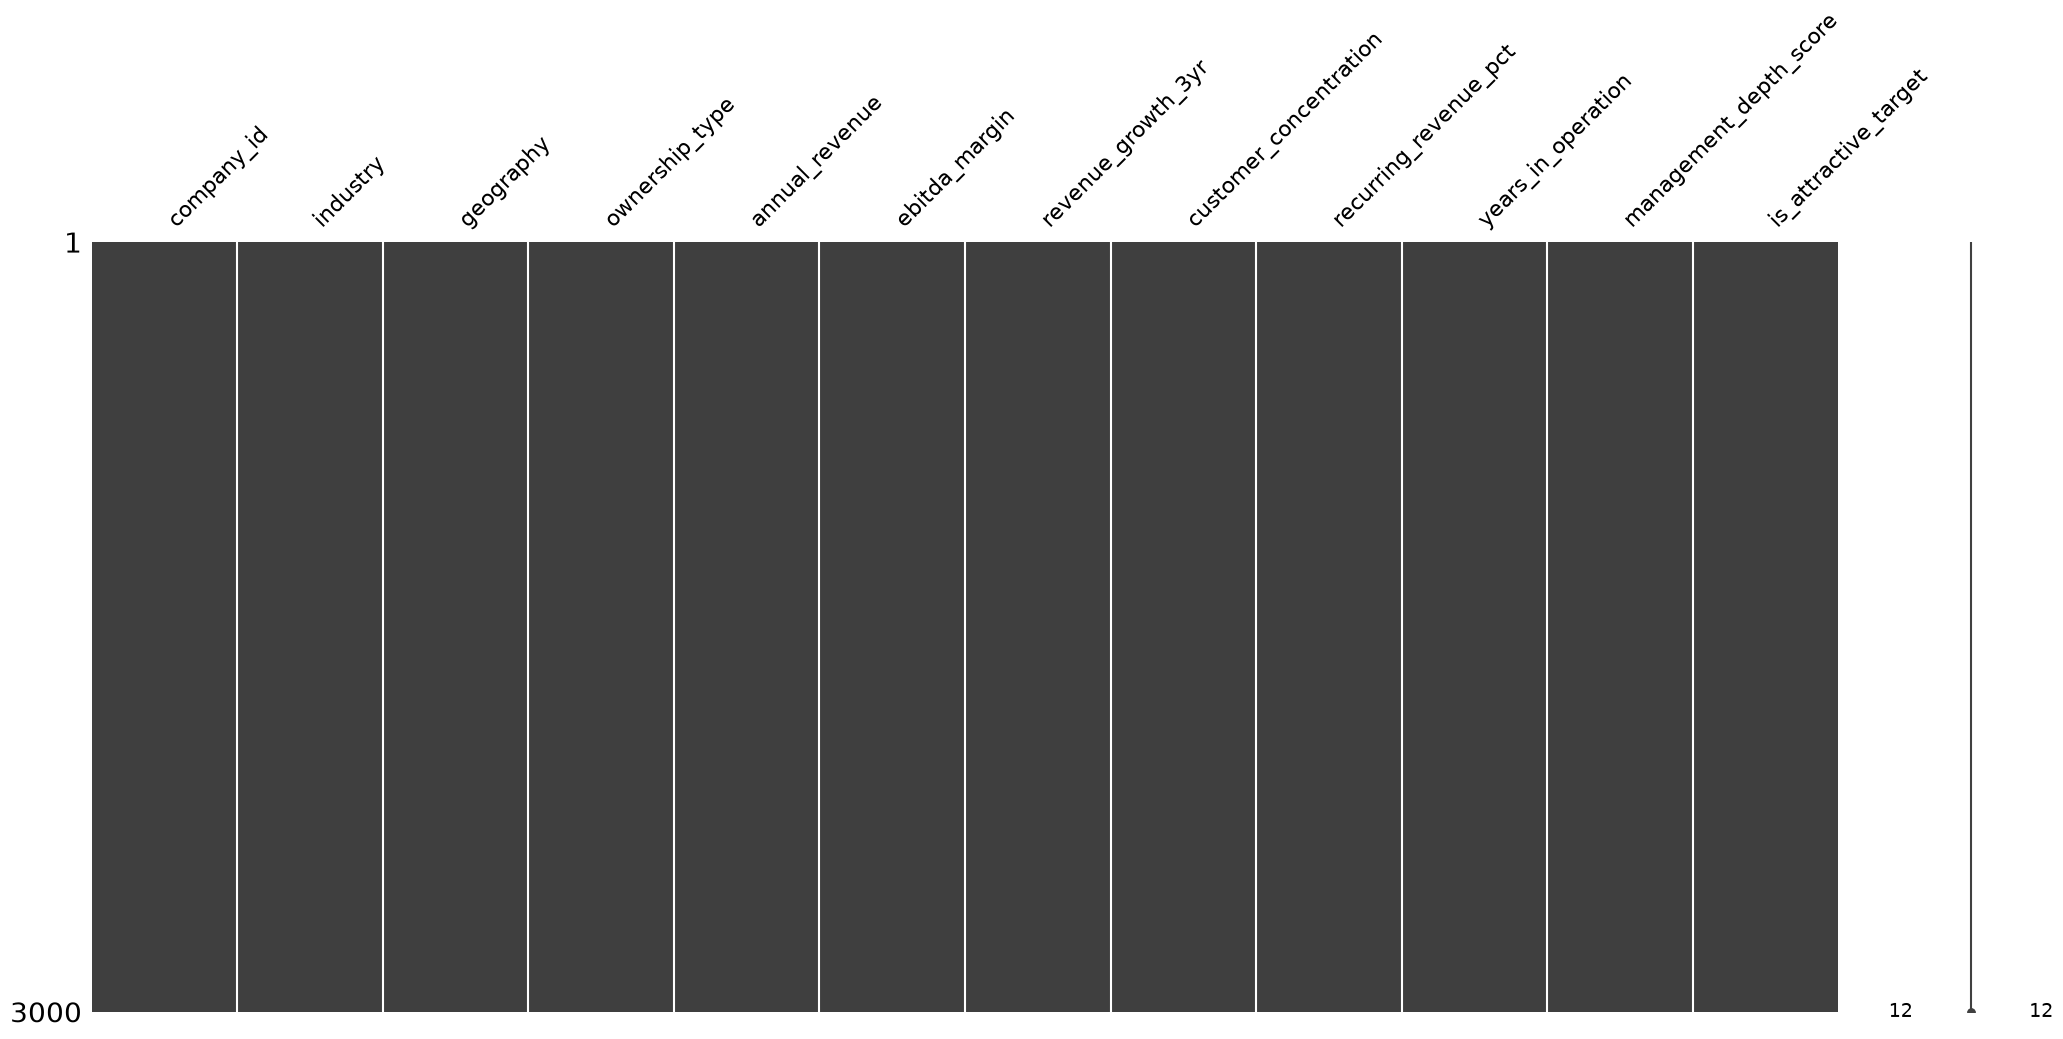

In [71]:
import missingno as msno
msno.matrix(veltro) # avec ca on a une visualisation des valeurs manquantes dans le dataset

In [72]:
veltro.duplicated().sum() # pour voir s'il y a des doublons dans le dataset

np.int64(0)

In [73]:
veltro.describe().T

,count,mean,std,min,25%,50%,75%,max
annual_revenue,3000.0,6.879764e+06,5.239363e+06,2.000000e+06,3.367750e+06,5.271000e+06,8.681250e+06,5.000000e+07
ebitda_margin,3000.0,1.358301e-01,6.502353e-02,1.000000e-02,9.040000e-02,1.273000e-01,1.724250e-01,4.150000e-01
revenue_growth_3yr,3000.0,8.178467e-02,1.473556e-01,-3.000000e-01,-1.947500e-02,8.285000e-02,1.834000e-01,6.071000e-01
customer_concentration,3000.0,2.504898e-01,1.424378e-01,3.100000e-03,1.423000e-01,2.306000e-01,3.378500e-01,8.012000e-01
recurring_revenue_pct,3000.0,3.156138e-01,2.369866e-01,0.000000e+00,1.353000e-01,2.540000e-01,4.603000e-01,9.500000e-01
years_in_operation,3000.0,1.362677e+01,7.079041e+00,3.000000e+00,8.700000e+00,1.210000e+01,1.680000e+01,7.030000e+01
management_depth_score,3000.0,2.810870e+00,9.003073e-01,1.000000e+00,2.180000e+00,2.810000e+00,3.430000e+00,5.000000e+00
is_attractive_target,3000.0,3.000000e-01,4.583340e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


In [74]:


def diagnostic_distributions(df, cols=None):
    if cols is None:
        cols = df.select_dtypes(include='number').columns
    
    resultats = []
    for col in cols:
        serie = df[col].dropna()
        if len(serie) < 3:
            continue
        
        skew = serie.skew() #on regarde l'asymétrie de la distribution
        kurt = serie.kurtosis() # on regarde la "pointedness" de la distribution(valeur extreme)
        
        # test de normalité adapté à la taille
        if len(serie) < 5000: # on regarde la pvalue
            _, p_norm = stats.shapiro(serie.sample(min(len(serie), 5000)))
        else:
            _, p_norm = stats.kstest(serie, 'norm', args=(serie.mean(), serie.std()))
        
        # détection outliers via IQR
        q1, q3 = serie.quantile([0.25, 0.75])
        iqr = q3 - q1
        n_outliers = ((serie < q1 - 1.5*iqr) | (serie > q3 + 1.5*iqr)).sum()
        pct_outliers = n_outliers / len(serie) * 100
        
        # on regarde la variance 
        variance = serie.std() /serie.mean() * 100
        resultats.append({
            'colonne': col,
            'skew': round(skew, 2),
            'kurtosis': round(kurt, 2),
            'p_normalite': round(p_norm, 4),
            'normale': p_norm > 0.05,
            'pct_outliers': round(pct_outliers, 1),
            'pct_manquant': round(serie.isnull().mean()*100, 1) if col in df else 0,
            'variance': round(variance, 2)
        })
    
    return pd.DataFrame(resultats)

diag = diagnostic_distributions(veltro.drop(columns=['is_attractive_target']))
diag

,colonne,skew,kurtosis,p_normalite,normale,pct_outliers,pct_manquant,variance
0,annual_revenue,2.23,7.16,0.0000,False,5.6,0.0,76.16
1,ebitda_margin,0.75,0.83,0.0000,False,2.3,0.0,47.87
2,revenue_growth_3yr,-0.01,-0.19,0.0178,False,0.2,0.0,180.18
3,customer_concentration,0.70,0.20,0.0000,False,1.3,0.0,56.86
4,recurring_revenue_pct,0.84,-0.08,0.0000,False,0.9,0.0,75.09
5,years_in_operation,1.66,5.08,0.0000,False,3.7,0.0,51.95
6,management_depth_score,0.11,-0.43,0.0000,False,0.0,0.0,32.03


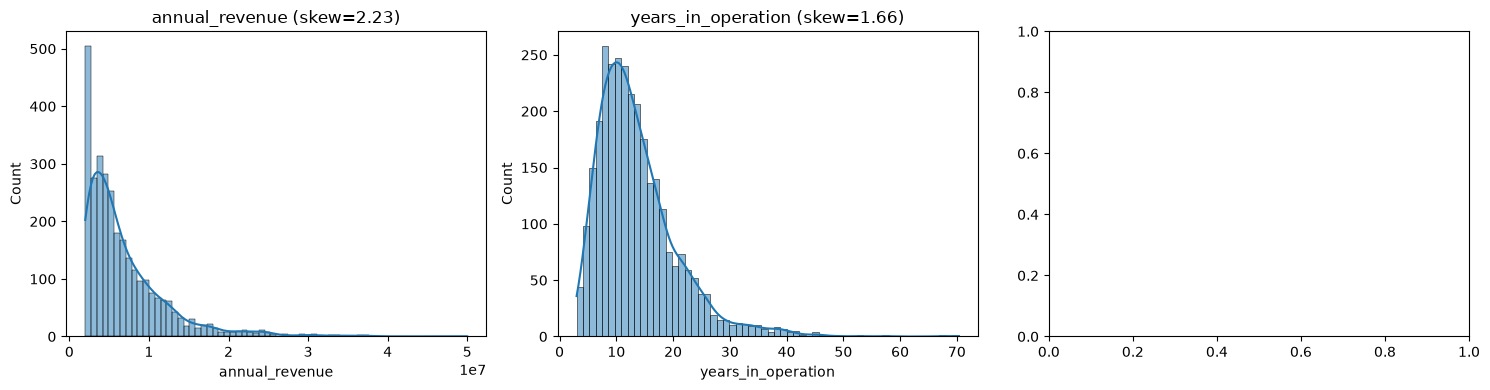

In [75]:
suspectes = diag[(diag['pct_outliers'] > 5) | (diag['skew'].abs() > 1)]['colonne'].tolist()

fig, axes = plt.subplots(len(suspectes[:12])//3 + 1, 3, figsize=(15, 4*(len(suspectes[:12])//3+1)))
for ax, col in zip(axes.flat, suspectes[:12]):
    sns.histplot(veltro[col], kde=True, ax=ax)
    ax.set_title(f"{col} (skew={veltro[col].skew():.2f})")
plt.tight_layout()

on a deux colonne qui pose reelement probleme que l'on doit traiter dans le pipeline 

In [76]:
veltro['ownership_type'].value_counts(normalize=True) * 100


ownership_type
Founder-owned        46.333333
Family-owned         23.900000
Already PE-backed    15.066667
Other                14.700000
Name: proportion, dtype: float64

In [77]:
table = pd.crosstab(veltro['ownership_type'], veltro['is_attractive_target'])
chi2, p_value, dof, expected = chi2_contingency(table)

print(f"p-value = {p_value:.4f}")

p-value = 0.4618


In [78]:
n = table.sum().sum()
r, k = table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r,k)-1)))
print(f"V de Cramér = {cramers_v:.3f}")

V de Cramér = 0.029


In [79]:
veltro['geography'].value_counts(normalize=True) * 100

geography
Southeast US     16.233333
West Coast US    14.800000
Midwest US       14.100000
Ontario          14.000000
Other            14.000000
Quebec           13.666667
Northeast US     13.200000
Name: proportion, dtype: float64

ici on tombe sur un petit probleme categorielle car on se sait pas l'information se situe dans le pays avec une granularité forte ou bien dans  les regions granularité faible 

In [80]:
veltro.groupby('geography')['is_attractive_target'].mean()  


geography
Midwest US       0.269504
Northeast US     0.285354
Ontario          0.307143
Other            0.283333
Quebec           0.304878
Southeast US     0.314168
West Coast US    0.331081
Name: is_attractive_target, dtype: float64

In [81]:
veltro.groupby(veltro['geography'].isin(['Ontario','Quebec']))['is_attractive_target'].mean()

geography
False    0.297696
True     0.306024
Name: is_attractive_target, dtype: float64

In [82]:
from scipy.stats import chi2_contingency

table = pd.crosstab(veltro['geography'], veltro['is_attractive_target'])
chi2, p_value, dof, expected = chi2_contingency(table)

print(f"p-value = {p_value:.4f}")

p-value = 0.4827


In [83]:
veltro['pays'] = veltro['geography'].isin(['Ontario','Quebec']).map({True:'Canada', False:'US_Other'})
table_pays = pd.crosstab(veltro['pays'], veltro['is_attractive_target'])
chi2_pays, p_pays, _, _ = chi2_contingency(table_pays)
print(f"p-value (Canada vs US_Other) = {p_pays:.4f}")

p-value (Canada vs US_Other) = 0.6886


ceque l'on constate avec la p vlaue est que meme si  on separe en pays ou laisse en granulé on a aucune infromation pour justifier que ces choix ont ou meme la classe  à un impact sur la cible on va alors la supprimer pour les modle lineaire et laisser en granulé pour les nom lineairez 

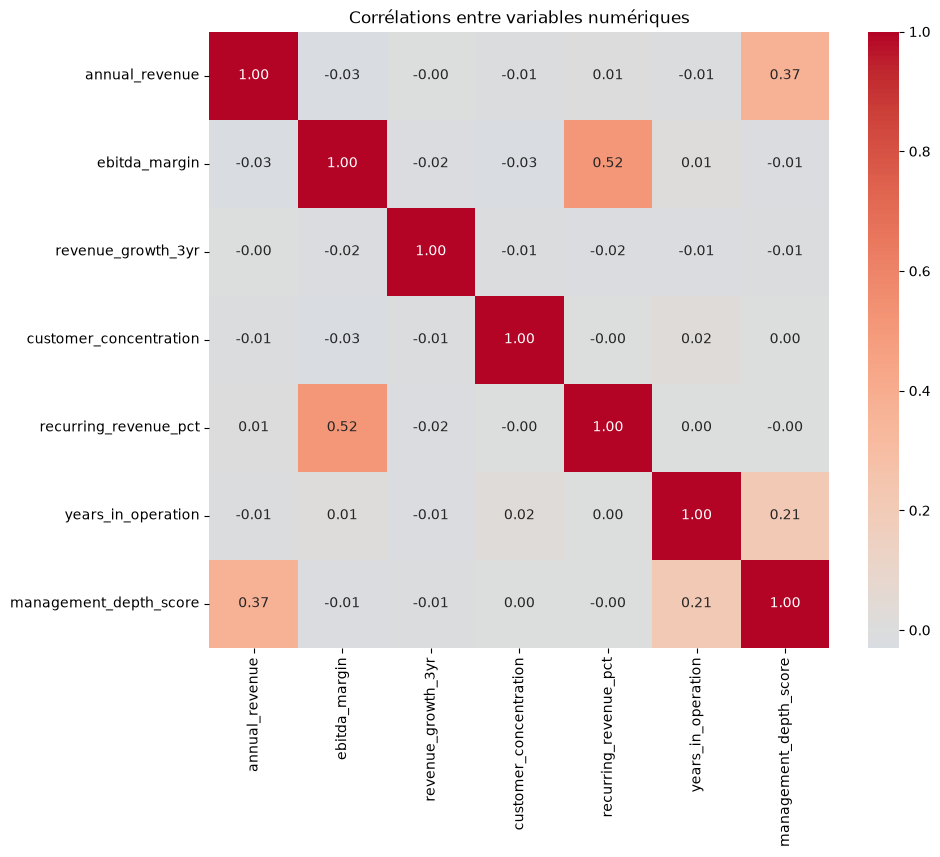

In [84]:

cols_numeriques = ['annual_revenue', 'ebitda_margin', 'revenue_growth_3yr',
                    'customer_concentration', 'recurring_revenue_pct',
                    'years_in_operation', 'management_depth_score']

corr = veltro[cols_numeriques].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Corrélations entre variables numériques')
plt.show()

In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = veltro[['ebitda_margin', 'recurring_revenue_pct']]

# Calcul du VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                Variable       VIF
0          ebitda_margin  3.714329
1  recurring_revenue_pct  3.714329


In [86]:
veltro[cols_numeriques].corrwith(veltro['is_attractive_target']).sort_values(key=abs, ascending=False)

recurring_revenue_pct     0.394533
ebitda_margin             0.363464
revenue_growth_3yr        0.247222
management_depth_score    0.230387
customer_concentration   -0.156687
years_in_operation        0.099472
annual_revenue            0.078526
dtype: float64

In [87]:
np.log1p(veltro['annual_revenue']).corr(veltro['is_attractive_target'])

np.float64(0.09200006248859781)

In [88]:
np.log1p(veltro['years_in_operation']).corr(veltro['is_attractive_target'])

np.float64(0.08822036913541252)

In [89]:
veltro['industry'].value_counts(normalize=True) * 100

industry
Business services          17.900000
Healthcare services        15.400000
Specialty manufacturing    13.633333
Consumer products          13.066667
Industrials                12.966667
Software                   12.400000
Distribution/logistics     10.200000
Other                       4.433333
Name: proportion, dtype: float64

In [90]:
table = pd.crosstab(veltro['industry'], veltro['is_attractive_target'])
chi2, p_value, dof, expected = chi2_contingency(table)

print(f"p-value = {p_value:.4f}")

p-value = 0.0000


In [91]:
veltro.groupby('industry')['is_attractive_target'].mean().sort_values(ascending=False)

industry
Software                   0.674731
Business services          0.405959
Healthcare services        0.318182
Other                      0.278195
Specialty manufacturing    0.202934
Industrials                0.190231
Distribution/logistics     0.147059
Consumer products          0.114796
Name: is_attractive_target, dtype: float64

In [92]:
n = table.sum().sum()
r, k = table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r,k)-1)))
print(f"V de Cramér = {cramers_v:.3f}")

V de Cramér = 0.373


ici on peut cosntater deux chose on a une p value de 0 cequi veuit dire que l'industrie à un impact sur la cible et le test de Cramer nous convient que cette liason n'est pas du hasard et cette variable doit rester dans lesdeux pipeline

In [93]:
veltro['is_attractive_target'].value_counts(normalize=True) * 100

is_attractive_target
0    70.0
1    30.0
Name: proportion, dtype: float64

In [94]:
veltro.duplicated().sum() # pour voir s'il y a des doublons dans le dataset

np.int64(0)

annual_revenue, years_in_operation → log/Yeo-Johnson pour le linéaire seulement
industry, ownership_type → one-hot dans les deux pipelines
geography → gardée pour arbres, exclue du linéaire
class_weight='balanced' sur les deux modèles (déséquilibre 70/30)
Split stratifié + cross_val_score avec scoring='f1' ou 'average_precision' pour comparer